# P-016 — Figures 1–3

Every number is read from an aggregate result artifact in `../artifacts/`.
No licensed microdata is used or required — see `../DATA_ACCESS.md`.
Outputs are stored, so figures render on GitHub without running anything.


## Setup


In [ ]:
import json, os
import numpy as np
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

ART = "../artifacts"
def A(n):
    with open(os.path.join(ART, n + ".json"), encoding="utf-8") as f: return json.load(f)

plt.rcParams.update({"font.family":"serif","font.size":9,"axes.linewidth":0.7,"axes.edgecolor":"0.3",
                     "legend.frameon":False,"figure.dpi":140})
INK="#1a1a1a"; MID="0.45"; BAND="0.86"   # 흑백 인쇄 대응: 색상 단독 부호화 없음
print("ready")


ready


## Figure 1 — Average gap and tail excess at pseudo-event dates and at the placement


Figure 1 — mean gap deepens toward the deal; tail excess is flat at every pseudo-date and jumps only at the placement.


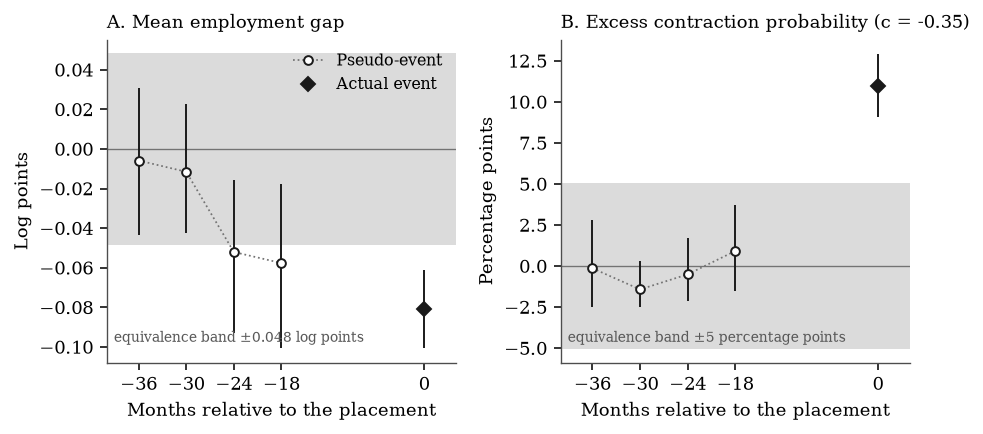

In [ ]:
fg = A("wp11fg"); g = fg["g_placebo_grid"]
order = ["t-36","t-30","t-24","t-18"]; x = [-36,-30,-24,-18,0]
mean    = [g[k]["mean"] for k in order] + [fg["f_honest"]["mean"]["effect"]]
mean_ci = [g[k]["mean_ci"] for k in order] + [fg["f_honest"]["mean"]["grid"][0]["ci"]]
tail    = [g[k]["tail"] for k in order] + [fg["f_honest"]["tail"]["effect"]]
tail_ci = [g[k]["tail_ci"] for k in order] + [fg["f_honest"]["tail"]["grid"][0]["ci"]]

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0), gridspec_kw={"wspace":0.30})
for ax,(y,ci,ses,ttl,ylab) in zip(axes, [
        (mean, mean_ci, fg["delta_mean"], "A. Mean employment gap", "Log points"),
        (tail, tail_ci, fg["delta_tail"], f"B. Excess contraction probability (c = {fg['c_tail']})", "Percentage points")]):
    k = 100.0 if ylab == "Percentage points" else 1.0
    y = [v*k for v in y]; ci = [[c[0]*k, c[1]*k] for c in ci]; ses = ses*k
    ax.axhspan(-ses, ses, color=BAND, zorder=0); ax.axhline(0, color=MID, lw=0.7, zorder=1)
    ax.vlines(x, [c[0] for c in ci], [c[1] for c in ci], color=INK, lw=1.0, zorder=2)
    ax.plot(x[:4], y[:4], marker="o", ms=4.5, mfc="white", mec=INK, mew=1.0, ls=":", color=MID, lw=0.9, zorder=3)
    ax.plot(x[4:], y[4:], marker="D", ms=5, mfc=INK, mec=INK, ls="none", zorder=4)
    ax.set_xticks(x); ax.set_xticklabels(["−36","−30","−24","−18","0"]); ax.set_xlim(-40, 4)
    ax.set_xlabel("Months relative to the placement"); ax.set_ylabel(ylab)
    ax.set_title(ttl, fontsize=9, loc="left", pad=6); ax.spines[["top","right"]].set_visible(False)
axes[0].legend(handles=[Line2D([],[],marker="o",ms=4.5,mfc="white",mec=INK,mew=1.0,ls=":",color=MID,lw=0.9,label="Pseudo-event"),
                        Line2D([],[],marker="D",ms=5,mfc=INK,mec=INK,ls="none",label="Actual event")],
               loc="upper right", fontsize=8)
for ax,lab in zip(axes, ["equivalence band ±0.048 log points","equivalence band ±5 percentage points"]):
    ax.text(0.02, 0.055, lab, transform=ax.transAxes, fontsize=7, color="0.35", va="bottom")
plt.show()
print("Figure 1 — mean gap deepens toward the deal; tail excess is flat at every pseudo-date and jumps only at the placement.")


## Figure 2 — The collapse-probability curve is not a threshold artifact


Figure 2 — the difference is positive at every threshold, so the result is not a threshold artifact.


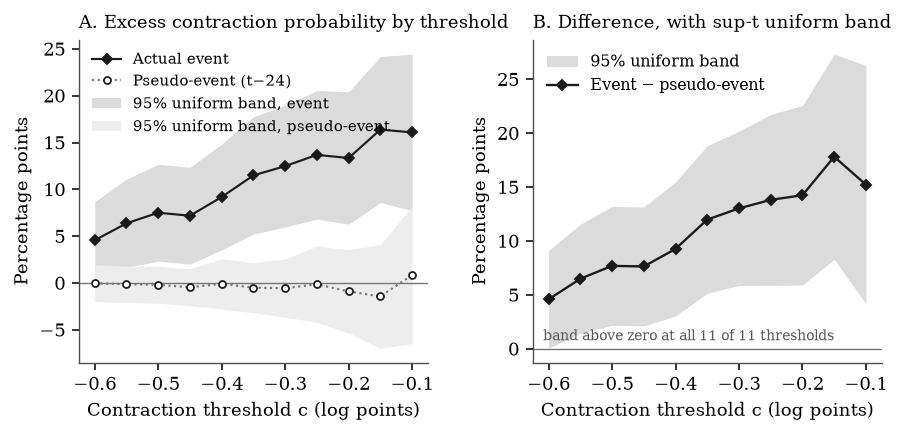

In [ ]:
d = A("wp11d"); grid = np.array(d["grid"]); K = 100.0
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0), gridspec_kw={"wspace":0.30})
ax = axes[0]
for key,mk,ls,fc,col,bandc in (("event","D","-",INK,INK,BAND), ("placebo","o",":","white",MID,"0.93")):
    ax.fill_between(grid, np.array(d[key]["lo_unif"])*K, np.array(d[key]["hi_unif"])*K, color=bandc, lw=0, zorder=1)
    ax.plot(grid, np.array(d[key]["point"])*K, marker=mk, ms=3.6, mfc=fc, mec=INK, mew=0.9, ls=ls, color=col, lw=1.1, zorder=3)
ax.axhline(0, color=MID, lw=0.7)
ax.set_title("A. Excess contraction probability by threshold", fontsize=9, loc="left", pad=6)
ax.set_xlabel("Contraction threshold c (log points)"); ax.set_ylabel("Percentage points")
ax.legend(handles=[Line2D([],[],marker="D",ms=3.6,color=INK,lw=1.1,label="Actual event"),
                   Line2D([],[],marker="o",ms=3.6,mfc="white",mec=INK,mew=0.9,ls=":",color=MID,lw=1.1,label="Pseudo-event (t−24)"),
                   Patch(facecolor=BAND,label="95% uniform band, event"),
                   Patch(facecolor="0.93",label="95% uniform band, pseudo-event")], loc="upper left", fontsize=7.5)
ax.spines[["top","right"]].set_visible(False)
ax = axes[1]
dd = np.array(d["ddd"]["point"])*K; lo = np.array(d["ddd"]["lo_unif"])*K; hi = np.array(d["ddd"]["hi_unif"])*K
ax.fill_between(grid, lo, hi, color=BAND, lw=0, zorder=1, label="95% uniform band")
ax.plot(grid, dd, marker="D", ms=3.6, color=INK, lw=1.2, zorder=3, label="Event − pseudo-event")
ax.axhline(0, color=MID, lw=0.7, zorder=2)
ax.set_title("B. Difference, with sup-t uniform band", fontsize=9, loc="left", pad=6)
ax.set_xlabel("Contraction threshold c (log points)"); ax.set_ylabel("Percentage points")
ax.legend(loc="upper left", fontsize=8); ax.spines[["top","right"]].set_visible(False)
ax.text(0.03, 0.07, f"band above zero at all {int((lo>0).sum())} of {len(grid)} thresholds",
        transform=ax.transAxes, fontsize=7, color="0.35")
plt.show()
print("Figure 2 — the difference is positive at every threshold, so the result is not a threshold artifact.")


## Figure 3 — Recipients versus non-recipients in the same measured distress state


Figure 3 — medians nearly identical within the same measured state; the lower tail diverges.
The shaded band is a visual reference only; equivalence is not formally tested for these quantiles.


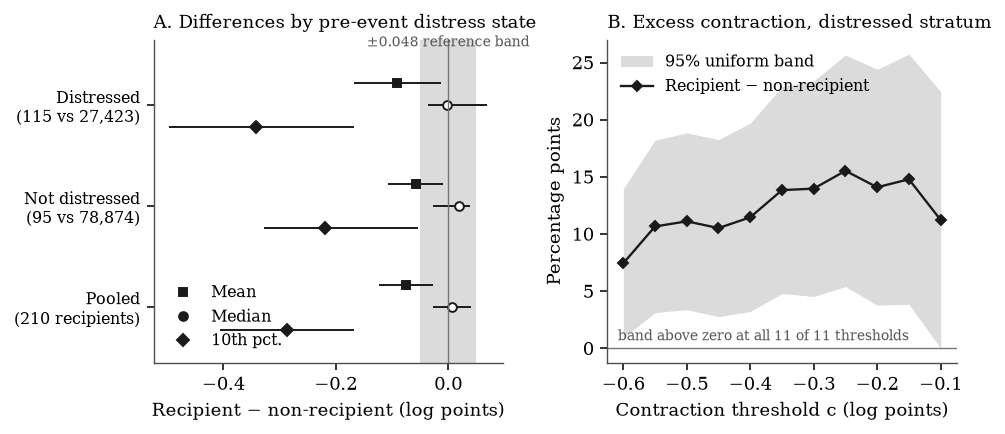

In [ ]:
b = A("wp12b")["runs"]
strata = [("B_distress_1","Distressed\n(115 vs 27,423)"), ("B_distress_0","Not distressed\n(95 vs 78,874)"),
          ("E_pool_distress","Pooled\n(210 recipients)")]
stats = [("mean","Mean"), ("median","Median"), ("p10","10th pct.")]
mks = {"mean":"s","median":"o","p10":"D"}
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0), gridspec_kw={"wspace":0.30})
ax = axes[0]; ypos = np.arange(len(strata))[::-1]
for j,(sk,slab) in enumerate(strata):
    r = b[sk]
    for i,(st,_) in enumerate(stats):
        y = ypos[j] + (1-i)*0.22; e = r[st]
        ax.plot([e["ci"][0], e["ci"][1]], [y,y], color=INK, lw=1.0, solid_capstyle="butt")
        ax.plot(e["obs"], y, marker=mks[st], ms=4.5, mfc=INK if e.get("sig") else "white", mec=INK, mew=1.0, ls="none")
ax.axvline(0, color=MID, lw=0.7); ax.axvspan(-0.048, 0.048, color=BAND, zorder=0)
ax.text(0.0, len(strata)-0.45, "±0.048 reference band", fontsize=7, color="0.35", ha="center", va="bottom")
ax.set_yticks(ypos); ax.set_yticklabels([s[1] for s in strata], fontsize=8)
ax.set_xlabel("Recipient − non-recipient (log points)")
ax.set_title("A. Differences by pre-event distress state", fontsize=9, loc="left", pad=6)
ax.legend(handles=[Line2D([],[],marker=mks[k],ms=4.5,mfc=INK,mec=INK,ls="none",label=l) for k,l in stats],
          loc="lower left", fontsize=8); ax.spines[["top","right"]].set_visible(False)
ax.set_ylim(-0.55, len(strata)-0.35)
ax = axes[1]
c = b["B_distress_1"]["curve"]; gg = np.array(c["grid"])
diff = np.array(c["diff"])*100; lo = np.array(c["lo_unif"])*100; hi = np.array(c["hi_unif"])*100
ax.fill_between(gg, lo, hi, color=BAND, lw=0, zorder=1, label="95% uniform band")
ax.plot(gg, diff, marker="D", ms=3.6, color=INK, lw=1.2, zorder=3, label="Recipient − non-recipient")
ax.axhline(0, color=MID, lw=0.7, zorder=2)
ax.set_title("B. Excess contraction, distressed stratum", fontsize=9, loc="left", pad=6)
ax.set_xlabel("Contraction threshold c (log points)"); ax.set_ylabel("Percentage points")
ax.legend(loc="upper left", fontsize=8); ax.spines[["top","right"]].set_visible(False)
ax.text(0.03, 0.07, f"band above zero at all {int((lo>0).sum())} of {len(gg)} thresholds",
        transform=ax.transAxes, fontsize=7, color="0.35")
plt.show()
print("Figure 3 — medians nearly identical within the same measured state; the lower tail diverges.")
print("The shaded band is a visual reference only; equivalence is not formally tested for these quantiles.")
